<a href="https://colab.research.google.com/github/vahabi9918/ridgelassoregression/blob/main/EDA_and_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Algerian_forest_fires_dataset.csv')

In [ ]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [ ]:
df.isnull().sum()

,0
day,1
month,2
year,2
Temperature,2
RH,2
Ws,2
Rain,2
FFMC,2
DMC,2
DC,2


In [ ]:
df.loc[:122, "Region"]=0
df.loc[122:, "Region"]=1

In [ ]:
df[['Region']] = df[['Region']].astype(int)

In [ ]:
df = df.dropna().reset_index(drop=True)

In [ ]:
df.isnull().sum()

,0
day,0
month,0
year,0
Temperature,0
RH,0
Ws,0
Rain,0
FFMC,0
DMC,0
DC,0


In [ ]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [ ]:
df = df.drop(122).reset_index(drop = True)

In [ ]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    object
 1   month        243 non-null    object
 2   year         243 non-null    object
 3   Temperature  243 non-null    object
 4   RH           243 non-null    object
 5   Ws           243 non-null    object
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 28.6+ KB


In [ ]:
df[['day','month','year','Temperature','RH','Ws']]=df[['day','month','year','Temperature','RH','Ws']].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    int64 
 1   month        243 non-null    int64 
 2   year         243 non-null    int64 
 3   Temperature  243 non-null    int64 
 4   RH           243 non-null    int64 
 5   Ws           243 non-null    int64 
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(7), object(8)
memory usage: 28.6+ KB


In [ ]:
# چاپ نام دقیق تمام ستون‌ها به همراه نوع داده
for col in df.columns:
    print(f"Column: '{col}' | Type: {df[col].dtype}")

# نمایش مقادیر غیرعددی در یکی از ستون‌ها
print("\nSample unique values in 'Temperature':")
print(df['Temperature'].unique()[:10])

Column: 'day' | Type: int64
Column: 'month' | Type: int64
Column: 'year' | Type: int64
Column: 'Temperature' | Type: int64
Column: 'RH' | Type: int64
Column: 'Ws' | Type: int64
Column: 'Rain' | Type: object
Column: 'FFMC' | Type: object
Column: 'DMC' | Type: object
Column: 'DC' | Type: object
Column: 'ISI' | Type: object
Column: 'BUI' | Type: object
Column: 'FWI' | Type: object
Column: 'Classes' | Type: object
Column: 'Region' | Type: int64

Sample unique values in 'Temperature':
[29 26 25 27 31 33 30 28 32 34]


In [ ]:
# ۱. حذف فاصله‌های خالی از نام ستون‌ها
df.columns = [col.strip() for col in df.columns]

# ۲. حذف سطر عنوان تکراری وسط دیتاسِت (بسیار مهم)
if 'Temperature' in df.columns:
    df = df[df['Temperature'] != 'Temperature'].copy()

# ۳. تبدیل تمام ستون‌ها (به جز classes) به float
for col in df.columns:
    if col.lower() != 'classes':
        # تبدیل اجباری به عدد (هر چیز غیرعددی NaN می‌شود)
        df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')

# ۴. بازنویسی اندیس‌ها
df = df.dropna().reset_index(drop=True)

# ۵. بررسی نتیجه
print(df.dtypes)

day              int64
month            int64
year             int64
Temperature      int64
RH               int64
Ws               int64
Rain           float64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
Classes         object
Region           int64
dtype: object


In [ ]:
df.to_csv('/content/drive/MyDrive/Colab Notebooks/Algerian_forest_fires_cleaned_dataset.csv',index=False)

EDA

In [ ]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
df_copy = df.drop(['day','month','year'], axis=1)

In [ ]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BFF,FWI,Classes
0,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
1,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
2,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
3,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
4,31,67,14,0,82.6,5.8,22.2,3.1,7,2.5,fire


In [ ]:
print(df['Classes'].unique())

['not fire   ' 'fire   ' 'fire' 'fire ' 'not fire' 'not fire ' nan
 'Classes  ' 'not fire     ' 'not fire    ']


In [ ]:
import numpy as np

# ۱. تغییر نام ستون آخر از 'not fire' به 'Classes'
df = df.rename(columns={'not fire': 'Classes'})

# ۲. ساخت df_copy
df_copy = df.copy()

# ۳. تبدیل متون به 0 و 1
classes_clean = df_copy['Classes'].astype(str).str.strip().str.lower()
df_copy['Classes'] = np.where(classes_clean.str.contains('not'), 0, 1)

# ۴. چک کردن خروجی (حالا هم 0 دارید هم 1)
print(df_copy['Classes'].value_counts())

Classes
1    141
0    105
Name: count, dtype: int64


In [ ]:
import numpy as np

# ۱. تعریف نام واقعی تمام ستون‌ها به ترتیب
column_names = [
    'Temperature', 'RH', 'Ws',
    'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BFF', 'FWI', 'Classes'
]

# ۲. اگر تعداد ستون‌ها ۱۴ تاست، نام‌ها را جایگزین کنید:
if len(df.columns) == 11:
    df.columns = column_names
else:
    print(f"تعداد ستون‌های شما {len(df.columns)} تا است، لطفاً تعداد را بررسی کنید.")

# ۳. حالا پاک‌سازی فاصله‌های اضافی
df.columns = df.columns.str.strip()

# ۴. ساخت df_copy و تبدیل Classes به 0 و 1
df_copy = df.copy()
classes_clean = df_copy['Classes'].astype(str).str.strip().str.lower()
df_copy['Classes'] = np.where(classes_clean.str.contains('not'), 0, 1)

# ۵. بررسی نتیجه
print("نام ستون‌های جدید:")
print(df_copy.columns)

print("\nتوزیع مقادیر 0 و 1 در ستون Classes:")
print(df_copy['Classes'].value_counts())

تعداد ستون‌های شما 14 تا است، لطفاً تعداد را بررسی کنید.
نام ستون‌های جدید:
Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BFF', 'FWI', 'Classes'],
      dtype='object')

توزیع مقادیر 0 و 1 در ستون Classes:
Classes
1    141
0    105
Name: count, dtype: int64


In [ ]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BFF', 'FWI', 'Classes'],
      dtype='object')

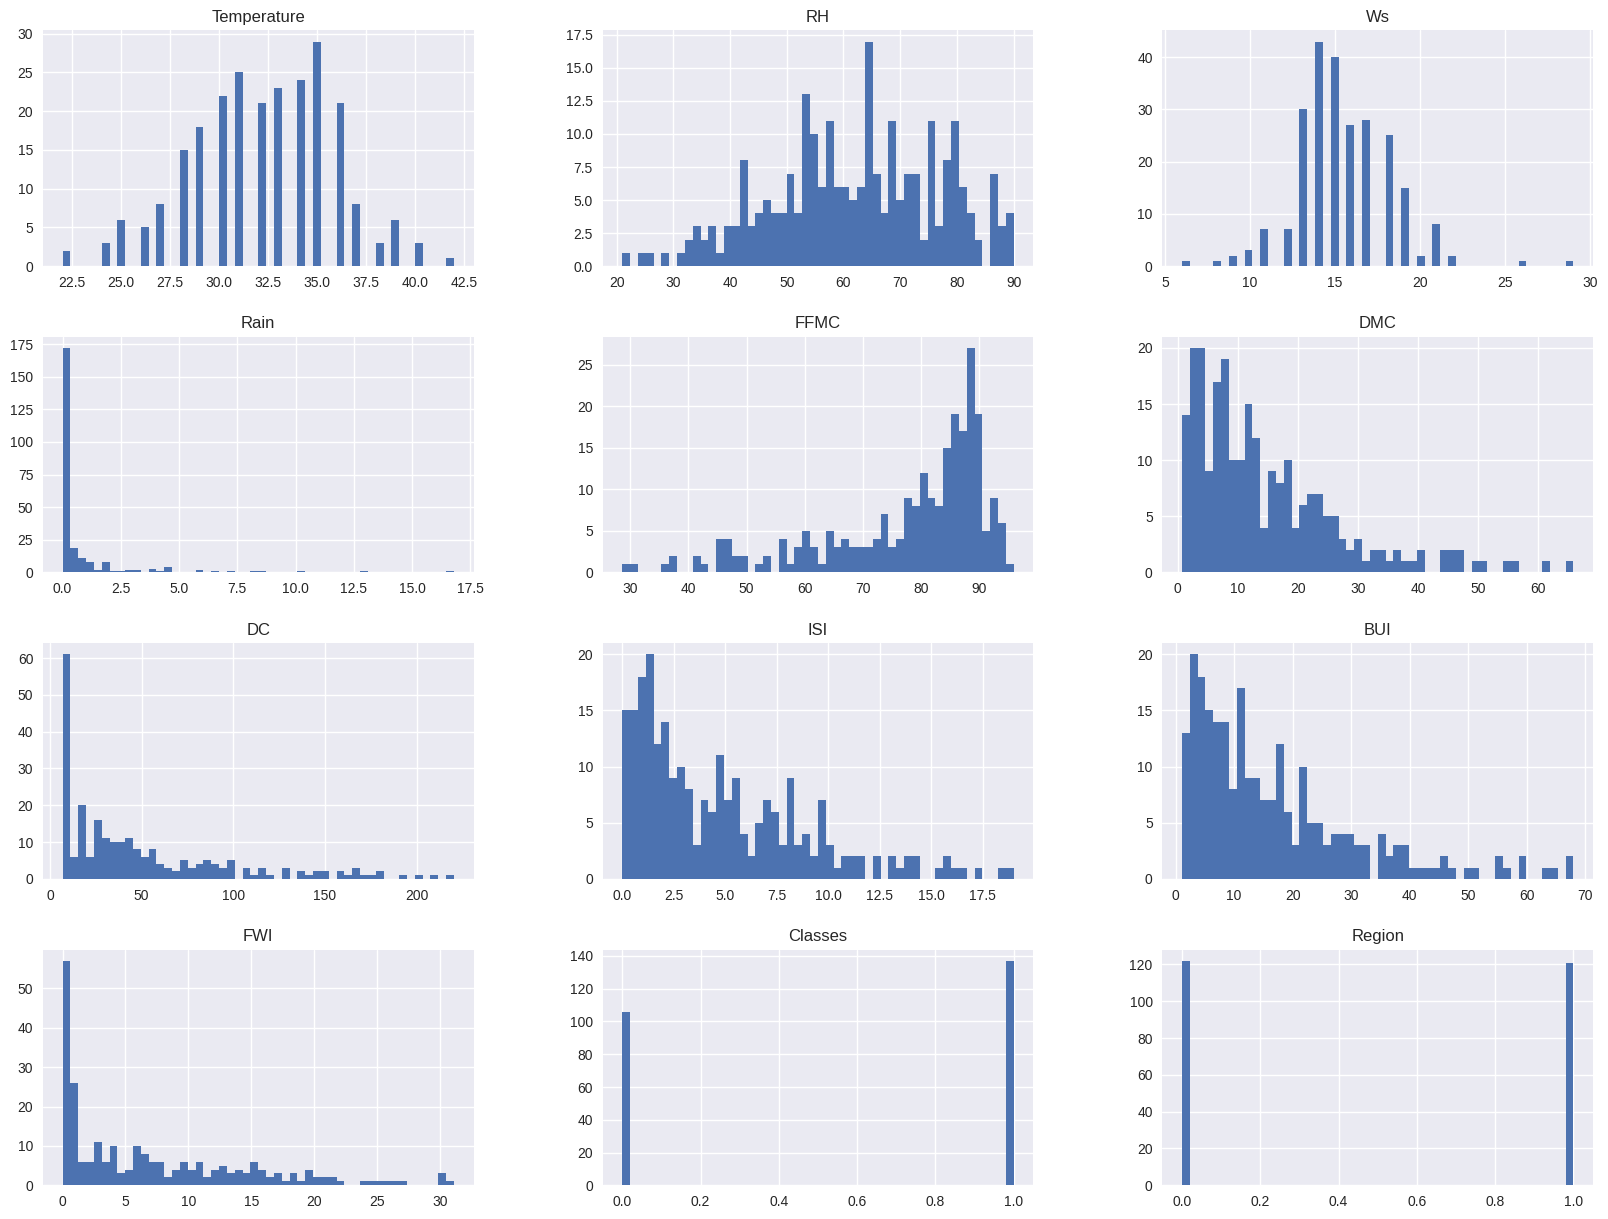

In [ ]:
plt.style.use('seaborn-v0_8')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

In [ ]:
#percentage for pie chart
percentage=df_copy['Classes'].value_counts(normalize=True)*100

Text(0.5, 1.0, 'Pie Chart of Classes')

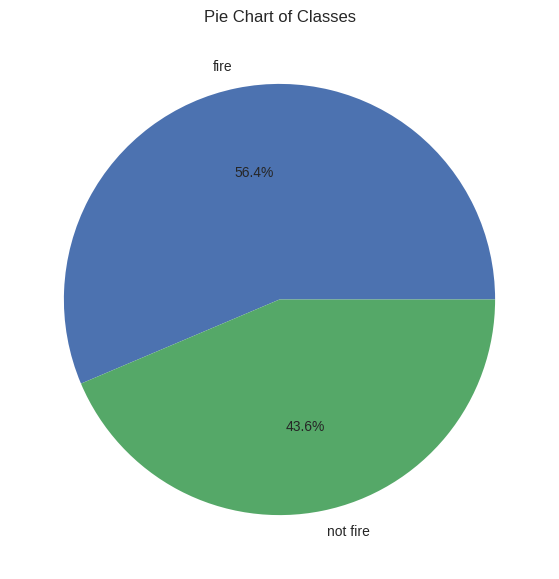

In [ ]:
classlabels = ['fire','not fire']
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%')
plt.title('Pie Chart of Classes')

In [ ]:
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


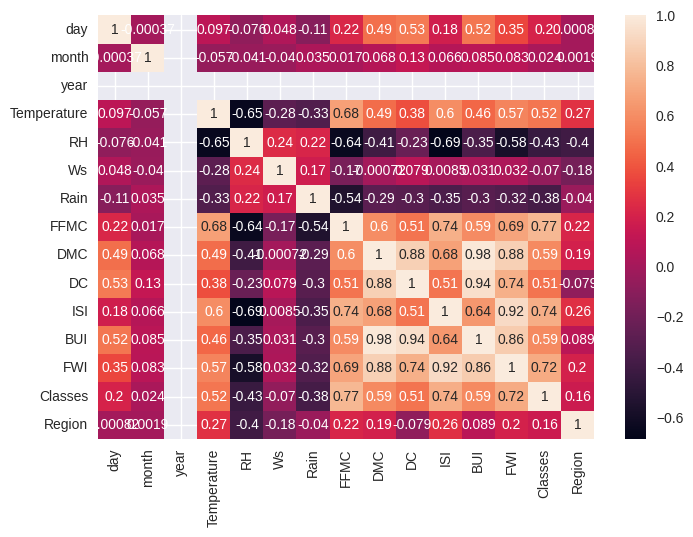

In [ ]:
# حذف فاصله‌های اضافی احتمالی در متن
df['Classes'] = df['Classes'].str.strip()

# تبدیل متن به عدد (مثلاً not fire -> 0 و fire -> 1)
df['Classes'] = df['Classes'].map({'not fire': 0, 'fire': 1})

# حالا رسم heatmap
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
import numpy as np

# ۱. حذف ردیف‌های شامل 'nan' و 'classes' (ردیف‌های نویز و تکراری)
df = df[~df['Classes_clean'].isin(['nan', 'classes'])]

# ۲. حذف هرگونه ردیف خالی (Missing values) باقی‌مانده و ریست کردن ایندکس
df = df.dropna().reset_index(drop=True)

# ۳. تبدیل نهایی به 0 و 1 روی داده‌های کاملا تمیز
df['Classes'] = np.where(df['Classes_clean'] == 'not fire', 0, 1)

# بررسی تعداد نهایی
print(df['Classes'].value_counts())

Classes
1    137
0    105
Name: count, dtype: int64


In [ ]:
# تبدیل ستون به رشته و سپس اعمال np.where
df['Classes'] = np.where(df['Classes'].astype(str).str.contains('not fire'), 'not fire', 'fire')

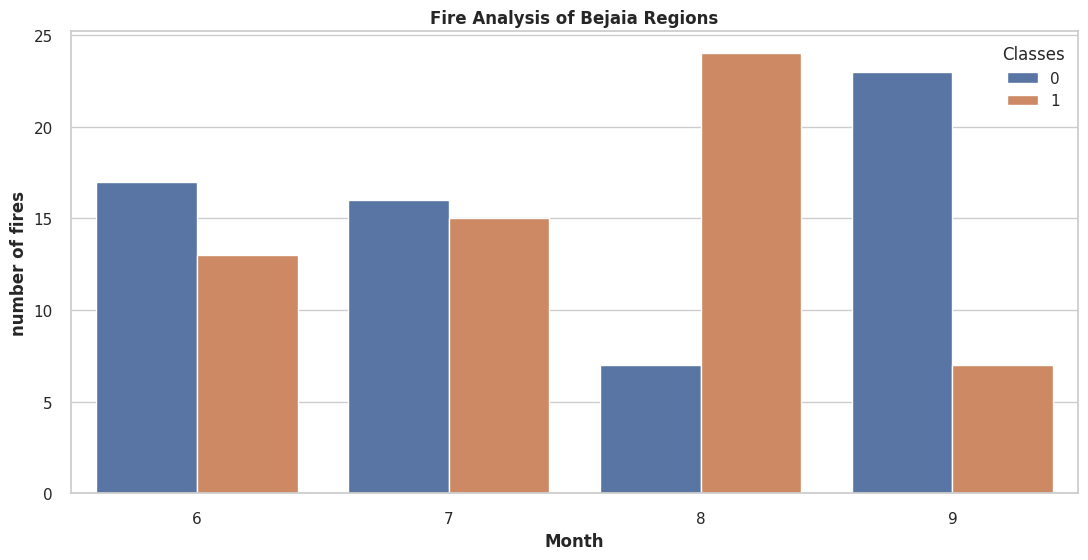

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ۱. حذف فاصله‌های اضافی از نام تمام ستون‌ها
df.columns = df.columns.str.strip()

# ۲. ایجاد ستون Region (۱۲۲ ردیف اول منطقه ۱ و بقیه منطقه ۲)
df['Region'] = 1
df.loc[122:, 'Region'] = 2

# ۳. فیلتر کردن منطقه ۱
dftemp = df.loc[df['Region'] == 1]

# ۴. رسم نمودار
plt.subplots(figsize=(13, 6))
sns.set_theme(style='whitegrid')

# از 'month' یا 'Month' با بررسی شرط زیر استفاده می‌کنیم
x_col = 'month' if 'month' in dftemp.columns else 'Month'
hue_col = 'Classes' if 'Classes' in dftemp.columns else 'classes'

sns.countplot(x=x_col, hue=hue_col, data=dftemp)

plt.ylabel('number of fires', weight='bold')
plt.xlabel('Month', weight='bold')
plt.title("Fire Analysis of Bejaia Regions", weight='bold')

plt.show()

In [ ]:
# اضافه کردن ستون Region
df.columns = df.columns.str.strip()
df['Region'] = 1
df.loc[122:, 'Region'] = 2

# پاک‌سازی متن Classes
df['Classes_clean'] = df['Classes'].astype(str).str.strip().str.lower()

# گزارش تفکیکی
print("--- منطقه ۱ (Bejaia) ---")
print(df[df['Region'] == 1]['Classes_clean'].value_counts())

print("\n--- منطقه ۲ (Sidi Bel-Abbes) ---")
print(df[df['Region'] == 2]['Classes_clean'].value_counts())

--- منطقه ۱ (Bejaia) ---
Classes_clean
0    63
1    59
Name: count, dtype: int64

--- منطقه ۲ (Sidi Bel-Abbes) ---
Classes_clean
1    78
0    42
Name: count, dtype: int64
